In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

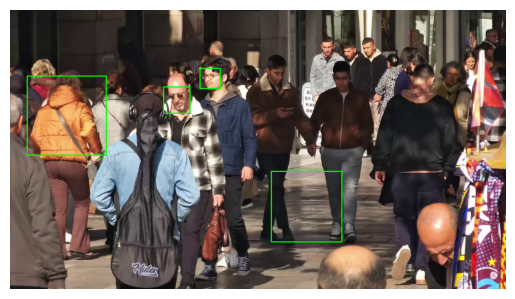

In [10]:
video_path = "/kaggle/input/datasets/nazaninashrafi/face-detection/11111.mp4"
cap = cv.VideoCapture(video_path)

face_cascade = cv.CascadeClassifier(
    cv.data.haarcascades + "haarcascade_frontalface_default.xml"
)


while True:
    # Frame Source
    ret,frame = cap.read()
    if not ret:
        print("File wasn't found")
        break

    # Preprocessing
    resized_frame = cv.resize(
        frame,
        None,
        fx = 0.5,
        fy = 0.5,
        interpolation= cv.INTER_AREA
    )
    gray_frame = cv.cvtColor(resized_frame, cv.COLOR_BGR2GRAY)

    # detecting possible face locations
    faces = face_cascade.detectMultiScale(
        gray_frame,
        scaleFactor=1.1,
        minNeighbors=5,
    )

    for (x,y,w,h) in faces:
        x,y,w,h = x*2, y*2, w*2, h*2
        cv.rectangle(
            frame,
            (x,y),
            (x+w, y+h),
            (0,255,0),
            2
        )

    # Visualization
    rgb_frame = cv.cvtColor(frame, cv.COLOR_BGR2RGB)
    plt.imshow(rgb_frame)
    plt.axis("off")
    plt.show()

    break

cap.release()